# Example 3 — CR3BP Trajectory Propagation

This example demonstrates translational propagation using the Circular Restricted Three-Body Problem (CR3BP), with the simulation initialized using normalized CR3BP quantities and converted to SI units.

## Notes and Setup

In [1]:
import numpy as np
from pathlib import Path
import sys

path = Path.cwd()

REPO_ROOT = path.parents[1]

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

As we are working with the CR3BP, usually it is in the normalized units. However, as the toolkit uses SI units, we need to define the correspondeant factors to make the respective translations between units

In [2]:
MU = 1.215e-2
TIME_FACTOR_SEC = 27.321661 / (2.0 * np.pi) * 24 * 3600     # time unit unidad -> sideral lunar month (days)
LENGTH_FACTOR = 384400.0e3

## General Simulation Setup

We start the simulation setup equally to the previous examples

### Environment

The environment object provides the simulation environment in which the spacecraft dynamics are evaluated.

In [3]:
# Define the environment
from py.modules.enviroments.environments import ClassicalEnvironment

env = ClassicalEnvironment() # NOTE: Need to review for proper implmentation of the environment class

### Simulation setup

The `Simulation` object defines the overall simulation horizon and environment. This works as a central orchestator for each spacecraft that will be added to the sim.

*Note: All the units in the simulations are in the Inertational Metric System*

In [4]:
from py.modules.new.simulation import Simulation

sim = Simulation(max_sim_time=0.75952417*2 * TIME_FACTOR_SEC,                 
                 environment= env,                 
                 verbose = True
)

## Spacecraft Creation
Similar to the second example, we will define an absolute sensor and a mission manager with a single phase.

As this is a basic case, where there is just translational motion, no other GNC or phases will be defined. This translational motion, could be propagated under different dynamics equations, in this case, we will use the `CR3BP` method.

In [5]:
from py.modules.propagators.native_propagator import NativeTranslationalPropagator
from py.modules.sensors.generic_sensor import AbsoluteSensor

translational_propagator = NativeTranslationalPropagator(dynamics="CR3BP", integration_method="NATIVE_RK45")

dt = 5e-4 * TIME_FACTOR_SEC 

sensors = [AbsoluteSensor(1/dt, verbose=False)]

In [6]:
from py.modules.navigation.basic_laws import IdealNavigation
from py.general.dataclasses import MissionPhase
from py.modules.new.mission_manager import MissionManager

nav_law = IdealNavigation()

phase = MissionPhase(
    name="Phase 1",
    navigation=nav_law,    
    dt_nav=dt,
    dt_propagation=dt,
    translational_model=translational_propagator
)

mission_manager = MissionManager(
    initial_phase=phase
) 

We now define the initial conditions for an NRHO orbit, and add the spacecraft to the simulation

In [7]:
initial_position = np.array([1.02262383, 0, -0.18250869]) * LENGTH_FACTOR # Initial position in meters
initial_velocity = np.array([0, -0.10456466, 0]) * LENGTH_FACTOR / TIME_FACTOR_SEC # Initial velocity in meters per second

sim.add_spacecraft(
    name="SC",
    initial_position=initial_position,
    initial_velocity=initial_velocity,
    sensors=sensors,
    mission_manager=mission_manager,
)

Spacecraft 'SC' added to the simulation.


## Simulation execution and results

We can now simulate and use some already built-in functions to graph the results.

In [8]:
# We can now simulate
result = sim.simulate()

Initializing simulation...
Spacecraft 'SC' dt_nav: 187.84990375046164, dt_guid: nan, dt_control: nan
Simulation initialized.
Starting simulation...
Simulation completed.


/home/afra/Documents/repos/ARGOS-Toolkit/py/modules/visualization/trajectories.py:1292: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(


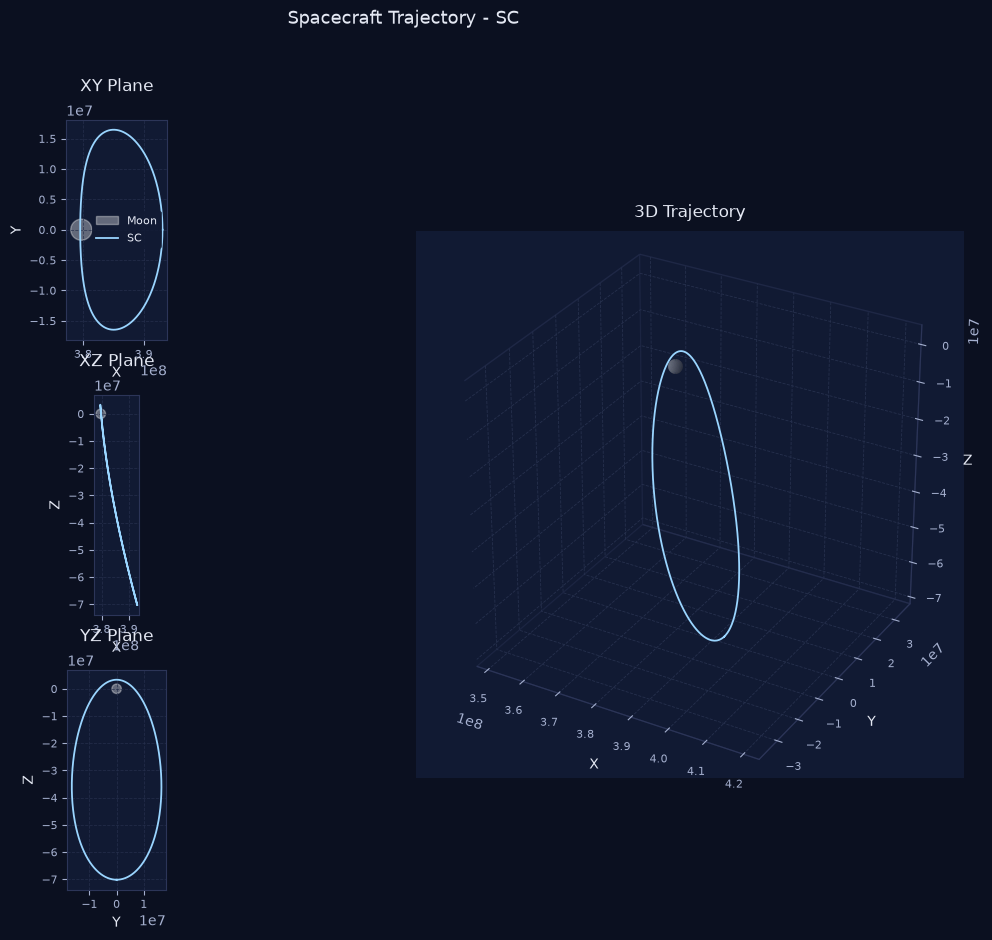

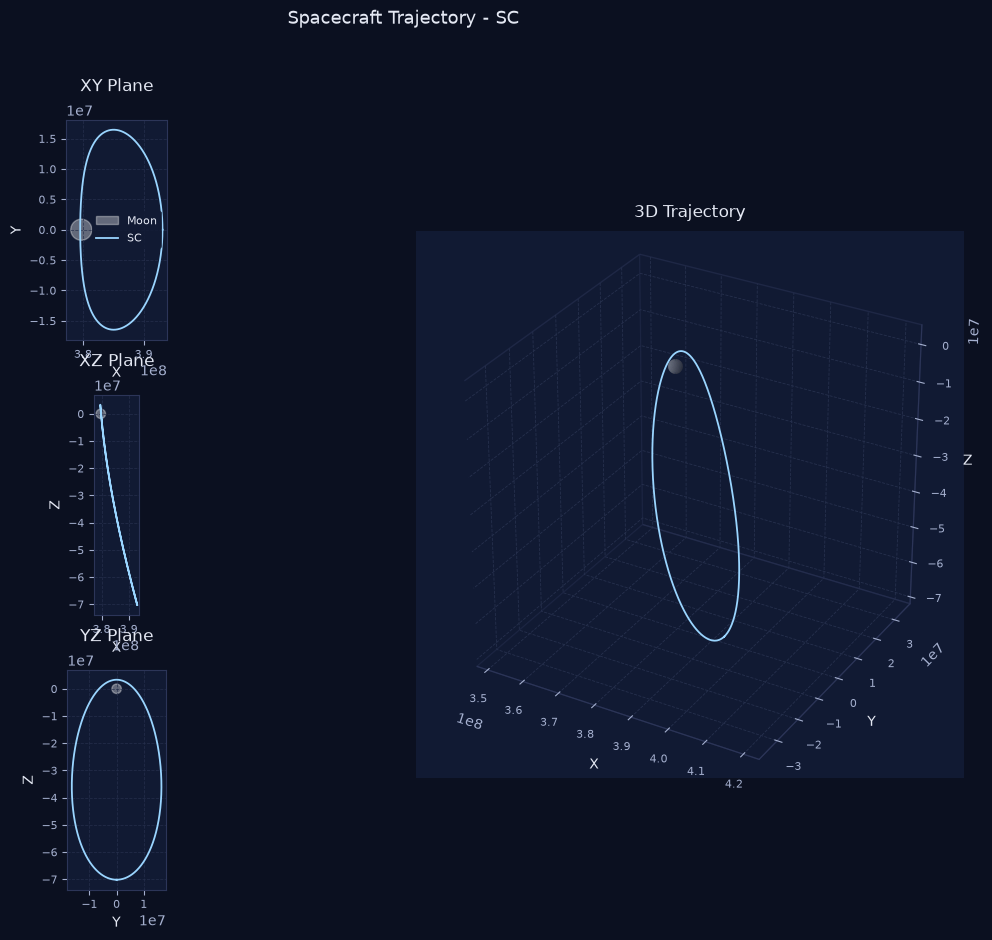

In [9]:
from py.modules.visualization.trajectories import *

plot_trajectory("SC", result, show=True, body="Moon",body_position=np.array([(1-MU)*LENGTH_FACTOR, 0.0, 0.0]),)